6 Month Analysis

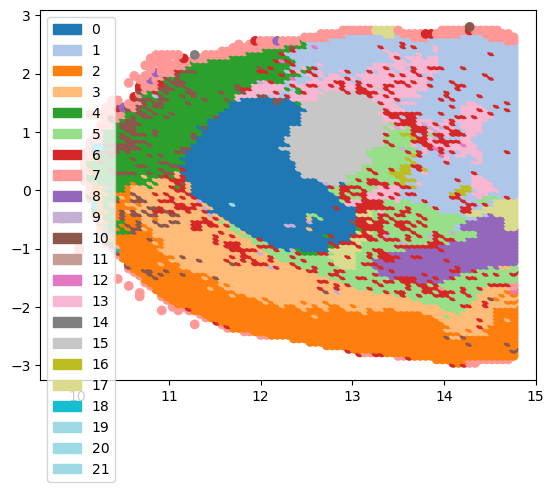

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


P-values of difference in WT and AD brains in cluster X
    884.5394  685.5149  729.5485  883.5340  883.5327  838.5569  862.6049  \
0   0.960505  0.643045  0.383485  0.588898  0.412536  0.528333  0.662886   
1   0.631685  0.438691  0.586138  0.851403  0.942221  0.609534  0.847291   
2   0.064313  0.392237  0.748287  0.003050  0.003050  0.064313  0.761047   
3   0.189533  0.424146  0.508367  0.010999  0.005805  0.121837  0.953465   
4   0.880042  0.482755  0.468613  0.697855  0.678978  0.468613  0.624833   
5   0.967544  0.254577  0.204161  0.765508  0.671894  0.715998  0.835824   
7   0.639962  0.843000  0.862107  0.455624  0.455624  0.729389  0.999671   
8   0.222294  0.031670  0.012980  0.063395  0.043073  0.009727  0.037083   
9   0.946710  0.940152  0.939322  0.940152  0.962711  0.939322  0.962711   
13  0.110041  0.055601  0.063363  0.174751  0.143321  0.507684  0.282152   
15  0.060183  0.393991  0.752101  0.082696  0.083329  0.271277  0.416469   
16  0.771047  0.906736  0.950139

In [1]:
from scipy import stats
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.multitest import multipletests

def map_labels_to_colors(labels, colormap="tab20"):
        unique_labels = np.unique(labels)
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i) for i in range(len(unique_labels))]
        label_to_color = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}
        return label_to_color

with open("data/lipid_names.txt", "r") as f:
    lipid_names = [line.strip() for line in f]
lipid_N_reduced_list = pd.read_csv('data/negative_globus_pallidus_ion_clustering_using_logfc_patterns_over_time.csv').iloc[:, 0].tolist()
reduced_indices = [lipid_names.index(item) for item in lipid_N_reduced_list]

clusters = np.load('checkpoints/clusters_[\'6moWT_0\', \'6moWT_1\', \'6moWT_2\', \'6moAD_0\', \'6moAD_1\', \'6moAD_2\'].npy')
label_to_color = map_labels_to_colors(clusters)
clusters[clusters == 11] = 15

coords = [np.load('data/6moWT_0_coords.npy'), np.load('data/6moWT_1_coords.npy'), np.load('data/6moWT_2_coords.npy'), np.load('data/6moAD_0_coords.npy'), np.load('data/6moAD_1_coords.npy'), np.load('data/6moAD_2_coords.npy')]
abundances = [np.load('data/6moWT_0_lipids.npy'), np.load('data/6moWT_1_lipids.npy'), np.load('data/6moAD_0_lipids.npy'), np.load('data/6moAD_1_lipids.npy'), np.load('data/6moAD_2_lipids.npy')]
clusters = np.hstack((clusters[0:coords[0].shape[0] + coords[1].shape[0]], clusters[coords[0].shape[0] + coords[1].shape[0] + coords[2].shape[0]:]))
coords = coords[0:2] + coords[3:]
for i in range(len(abundances)):
    abundances[i] = abundances[i][:, reduced_indices]
    abundances[i] = abundances[i] / abundances[i].sum(axis=1, keepdims=True)
    
# 1. Concatenate the arrays along the first axis (axis=0)
concatenated = np.vstack(abundances)  # Concatenate along rows (n dimension)

# 2. Z-score normalization across the concatenated array (column-wise normalization)
concatenated_zscore = (concatenated - concatenated.mean(axis=0)) / concatenated.std(axis=0)

# 3. Split the concatenated and normalized array back into the original arrays
abundances = np.split(concatenated_zscore, np.cumsum([arr.shape[0] for arr in abundances])[:-1])

data = []
curr = 0
i = 0
for c in coords:
    data.append((c, clusters[curr:curr + c.shape[0]], abundances[i]))
    curr += c.shape[0]
    i+= 1

hemispheres = []
i = 0
for (c, l, a) in data:
    if i != 4:
        median_x_coord = np.median(c[:, 0])
        hemispheres.append((c[np.where(c[:, 0] < median_x_coord)[0]], l[np.where(c[:, 0] < median_x_coord)[0]], a[np.where(c[:, 0] < median_x_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 0] >= median_x_coord)[0]], l[np.where(c[:, 0] >= median_x_coord)[0]], a[np.where(c[:, 0] >= median_x_coord)[0]]))
    else:
        median_y_coord = np.median(c[:, 1])
        hemispheres.append((c[np.where(c[:, 1] < median_y_coord)[0]], l[np.where(c[:, 1] < median_y_coord)[0]], a[np.where(c[:, 1] < median_y_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 1] >= median_y_coord)[0]], l[np.where(c[:, 1] >= median_y_coord)[0]], a[np.where(c[:, 1] >= median_y_coord)[0]]))
    i += 1

WT = hemispheres[0:4]
AD = hemispheres[4:]
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in label_to_color.items()]
for h in WT[0:1]:
    plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=[label_to_color[label] for label in h[1]])
    plt.legend(handles=legend_patches)
    plt.show()

res = {}
for cluster in np.unique(clusters):
    p_values = []
    for ion in range(WT[0][2].shape[1]):
        wt_means = []
        ad_means = []
        for x in WT:
            wt_means.append(np.mean(x[2][x[1] == cluster, ion]))
        for x in AD:
            ad_means.append(np.mean(x[2][x[1] == cluster, ion]))
        t_stat, p_value = stats.ttest_ind(wt_means, ad_means)
        p_values.append(p_value)
    _, p_values, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
    res[cluster] = {}
    for i in range(len(p_values)):
        res[cluster][lipid_N_reduced_list[i]] = p_values[i]

df = pd.DataFrame.from_dict(res, orient='index')
df.dropna(inplace=True)
df.to_csv('6mo-pval.csv')
print('P-values of difference in WT and AD brains in cluster X')
print(df.head(20))


12 Month Analysis

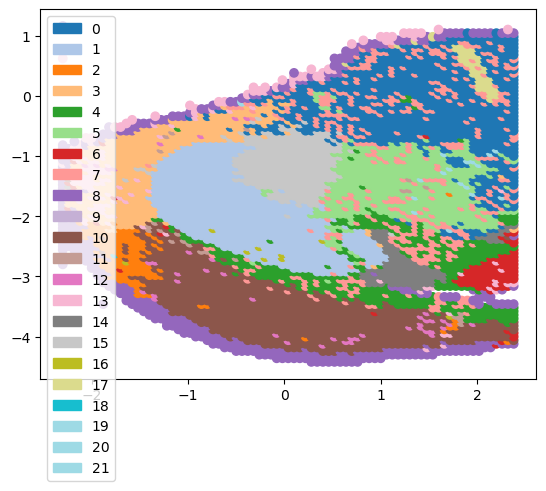

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


P-values of difference in WT and AD brains in cluster X
    884.5394  685.5149  729.5485  883.5340  883.5327  838.5569  862.6049  \
0   0.991800  0.991800  0.991800  0.991800  0.991800  0.991800  0.991800   
1   0.754244  0.628389  0.759526  0.754244  0.754244  0.759526  0.718199   
2   0.708895  0.879652  0.807161  0.807161  0.522790  0.875227  0.932442   
3   0.869384  0.900321  0.964088  0.900321  0.869384  0.945424  0.945424   
4   0.914470  0.914470  0.914470  0.929681  0.929681  0.928190  0.914470   
5   0.981137  0.981137  0.981137  0.981137  0.981137  0.981137  0.981137   
6   0.260588  0.441365  0.361138  0.260588  0.260588  0.318515  0.973750   
7   0.997696  0.997696  0.997696  0.997696  0.997696  0.997696  0.997696   
8   0.589291  0.354892  0.303634  0.503288  0.486618  0.790977  0.686893   
11  0.883585  0.836783  0.869344  0.944000  0.854660  0.944000  0.854660   
14  0.937559  0.009465  0.071497  0.910753  0.914120  0.774277  0.025808   
15  0.187223  0.921749  0.301009

In [2]:
clusters = np.load('checkpoints/clusters_[\'12moWT_0\', \'12moWT_1\', \'12moWT_2\', \'12moAD_0\', \'12moAD_1\', \'12moAD_2\'].npy')
label_to_color = map_labels_to_colors(clusters)
clusters[clusters == 9] = 15

coords = [np.load('data/12moWT_0_coords.npy'), np.load('data/12moWT_1_coords.npy'), np.load('data/12moWT_2_coords.npy'), np.load('data/12moAD_0_coords.npy'), np.load('data/12moAD_1_coords.npy'), np.load('data/12moAD_2_coords.npy')]
abundances = [np.load('data/12moWT_0_lipids.npy'), np.load('data/12moWT_1_lipids.npy'), np.load('data/12moWT_2_lipids.npy'), np.load('data/12moAD_0_lipids.npy'), np.load('data/12moAD_1_lipids.npy'), np.load('data/12moAD_2_lipids.npy')]
for i in range(len(abundances)):
    abundances[i] = abundances[i][:, reduced_indices]
    abundances[i] = abundances[i] / abundances[i].sum(axis=1, keepdims=True)
    
# 1. Concatenate the arrays along the first axis (axis=0)
concatenated = np.vstack(abundances)  # Concatenate along rows (n dimension)

# 2. Z-score normalization across the concatenated array (column-wise normalization)
concatenated_zscore = (concatenated - concatenated.mean(axis=0)) / concatenated.std(axis=0)

# 3. Split the concatenated and normalized array back into the original arrays
abundances = np.split(concatenated_zscore, np.cumsum([arr.shape[0] for arr in abundances])[:-1])

data = []
curr = 0
i = 0
for c in coords:
    data.append((c, clusters[curr:curr + c.shape[0]], abundances[i]))
    curr += c.shape[0]
    i+= 1

hemispheres = []
i = 0
for (c, l, a) in data:
    if i == 0  or i == 1 or i == 3 or i == 5:
        median_x_coord = np.median(c[:, 0])
        hemispheres.append((c[np.where(c[:, 0] < median_x_coord)[0]], l[np.where(c[:, 0] < median_x_coord)[0]], a[np.where(c[:, 0] < median_x_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 0] >= median_x_coord)[0]], l[np.where(c[:, 0] >= median_x_coord)[0]], a[np.where(c[:, 0] >= median_x_coord)[0]]))
    else:
        median_y_coord = np.median(c[:, 1])
        hemispheres.append((c[np.where(c[:, 1] < median_y_coord)[0]], l[np.where(c[:, 1] < median_y_coord)[0]], a[np.where(c[:, 1] < median_y_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 1] >= median_y_coord)[0]], l[np.where(c[:, 1] >= median_y_coord)[0]], a[np.where(c[:, 1] >= median_y_coord)[0]]))
    i += 1

WT = hemispheres[0:6]
AD = hemispheres[6:]
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in label_to_color.items()]
for h in WT[0:1]:
    plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=[label_to_color[label] for label in h[1]])
    plt.legend(handles=legend_patches)
    plt.show()

res = {}
for cluster in np.unique(clusters):
    p_values = []
    for ion in range(WT[0][2].shape[1]):
        wt_means = []
        ad_means = []
        for x in WT:
            wt_means.append(np.mean(x[2][x[1] == cluster, ion]))
        for x in AD:
            ad_means.append(np.mean(x[2][x[1] == cluster, ion]))
        t_stat, p_value = stats.ttest_ind(wt_means, ad_means)
        p_values.append(p_value)
    _, p_values, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
    res[cluster] = {}
    for i in range(len(p_values)):
        res[cluster][lipid_N_reduced_list[i]] = p_values[i]
df = pd.DataFrame.from_dict(res, orient='index')
df.dropna(inplace=True)
df.to_csv('12mo-pval.csv')
print('P-values of difference in WT and AD brains in cluster X')
print(df.head(20))

22 Month Analysis

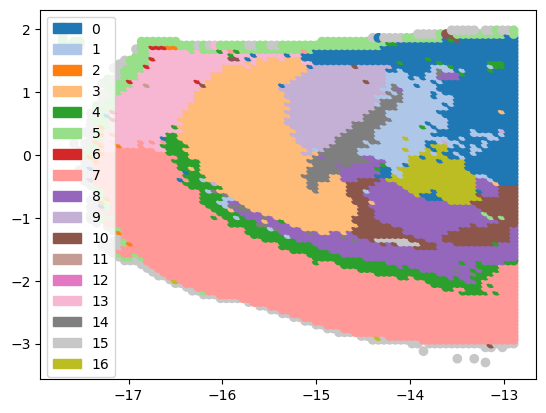

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


P-values of difference in WT and AD brains in cluster X
    884.5394  685.5149  729.5485  883.5340  883.5327  838.5569  862.6049  \
0   0.050800  0.656816  0.459528  0.050800  0.124864  0.131184  0.651346   
1   0.044109  0.527720  0.680621  0.034884  0.072872  0.174459  0.214902   
2   0.015323  0.884497  0.267052  0.015323  0.043433  0.376901  0.552672   
3   0.130164  0.494369  0.323502  0.124545  0.153613  0.179765  0.535899   
4   0.320662  0.540039  0.108831  0.098991  0.296458  0.084172  0.059609   
5   0.976433  0.499821  0.631142  0.674847  0.833737  0.518753  0.499821   
6   0.454929  0.981839  0.472454  0.217115  0.281421  0.300036  0.775761   
7   0.955012  0.686860  0.553141  0.501495  0.553141  0.831291  0.981896   
8   0.104148  0.182179  0.894081  0.079523  0.145910  0.124560  0.114491   
9   0.924705  0.695774  0.468376  0.529537  0.683708  0.413080  0.326819   
10  0.673981  0.855217  0.668914  0.752002  0.741346  0.068552  0.162261   
11  0.430244  0.646582  0.430244

In [3]:
clusters = np.load('checkpoints/clusters_[\'22moWT_0\', \'22moWT_1\', \'22moWT_2\', \'22moAD_0\', \'22moAD_1\', \'22moAD_2\'].npy')
label_to_color = map_labels_to_colors(clusters)

coords = [np.load('data/22moWT_0_coords.npy'), np.load('data/22moWT_1_coords.npy'), np.load('data/22moWT_2_coords.npy'), np.load('data/22moAD_0_coords.npy'), np.load('data/22moAD_1_coords.npy'), np.load('data/22moAD_2_coords.npy')]
abundances = [np.load('data/22moWT_0_lipids.npy'), np.load('data/22moWT_1_lipids.npy'), np.load('data/22moWT_2_lipids.npy'), np.load('data/22moAD_0_lipids.npy'), np.load('data/22moAD_1_lipids.npy'), np.load('data/22moAD_2_lipids.npy')]
for i in range(len(abundances)):
    abundances[i] = abundances[i][:, reduced_indices]
    abundances[i] = abundances[i] / abundances[i].sum(axis=1, keepdims=True)
    
# 1. Concatenate the arrays along the first axis (axis=0)
concatenated = np.vstack(abundances)  # Concatenate along rows (n dimension)

# 2. Z-score normalization across the concatenated array (column-wise normalization)
concatenated_zscore = (concatenated - concatenated.mean(axis=0)) / concatenated.std(axis=0)

# 3. Split the concatenated and normalized array back into the original arrays
abundances = np.split(concatenated_zscore, np.cumsum([arr.shape[0] for arr in abundances])[:-1])

data = []
curr = 0
i = 0
for c in coords:
    data.append((c, clusters[curr:curr + c.shape[0]], abundances[i]))
    curr += c.shape[0]
    i+= 1

hemispheres = []
i = 0
for (c, l, a) in data:
    if i == 0:
        median_x_coord = np.median(c[:, 0])
        hemispheres.append((c[np.where(c[:, 0] < median_x_coord)[0]], l[np.where(c[:, 0] < median_x_coord)[0]], a[np.where(c[:, 0] < median_x_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 0] >= median_x_coord)[0]], l[np.where(c[:, 0] >= median_x_coord)[0]], a[np.where(c[:, 0] >= median_x_coord)[0]]))
    else:
        median_y_coord = np.median(c[:, 1])
        hemispheres.append((c[np.where(c[:, 1] < median_y_coord)[0]], l[np.where(c[:, 1] < median_y_coord)[0]], a[np.where(c[:, 1] < median_y_coord)[0]]))
        hemispheres.append((c[np.where(c[:, 1] >= median_y_coord)[0]], l[np.where(c[:, 1] >= median_y_coord)[0]], a[np.where(c[:, 1] >= median_y_coord)[0]]))
    i += 1

WT = hemispheres[0:6]
AD = hemispheres[6:]
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in label_to_color.items()]
for h in WT[0:1]:
    plt.scatter(x=h[0][:, 0], y=h[0][:, 1], c=[label_to_color[label] for label in h[1]])
    plt.legend(handles=legend_patches)
    plt.show()

res = {}
for cluster in np.unique(clusters):
    p_values = []
    for ion in range(WT[0][2].shape[1]):
        wt_means = []
        ad_means = []
        for x in WT:
            wt_means.append(np.mean(x[2][x[1] == cluster, ion]))
        for x in AD:
            ad_means.append(np.mean(x[2][x[1] == cluster, ion]))
        t_stat, p_value = stats.ttest_ind(wt_means, ad_means)
        p_values.append(p_value)
    _, p_values, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
    res[cluster] = {}
    for i in range(len(p_values)):
        res[cluster][lipid_N_reduced_list[i]] = p_values[i]
df = pd.DataFrame.from_dict(res, orient='index')
df.dropna(inplace=True)
df.to_csv('22mo-pval.csv')
print('P-values of difference in WT and AD brains in cluster X')
print(df.head(20))